# UC2 — HEK293 heterogeneous biology graph as one AnnNet object

A heterogeneous, hyperedge-rich, cell-line-specific biological network where
**AnnNet is the single container** for four biological processes, two vertex
kinds, the cross-layer coupling that ties them together, compartment
overlays, heterogeneous queries, an inferential downstream task, and
lossless exports.

The four biological processes are represented as **Kivelä elementary
layers** on a single aspect (`level`). Each protein is a distinct
*supra-node* per layer it participates in (a "signaling-TP53" entity, a
"regulatory-TP53" entity, etc.), bound back together by inter-layer
coupling edges:

- `signaling` — OmniPath directed protein–protein interactions
- `metabolic` — Human-GEM stoichiometric hyperedges (signed coefficients)
- `complex`   — OmniPath protein complexes as undirected hyperedges
- `regulatory` — DoRothEA TF→target directed edges (confidence A+B)

Inter-layer coupling: `(prot:X, signaling) ↔ (prot:X, complex)` and similar
links between the same protein's supra-nodes carry information across
layers. `gene → prot` translation and TF→anchor edges bridge gene
supra-nodes (regulatory layer) and protein supra-nodes (signaling layer).

**Compartments stay as slices.** HPA subcellular localisation is an
overlay on the shared graph — proteins can live in multiple compartments
and the membership is orthogonal to the layer model.

Cell-line specificity is enforced once, up front, by filtering every
external source to genes with HPA protein-level evidence.

**What AnnNet provides that nothing else does, exercised here**

- one container for four heterogeneous Kivelä layers + inter-layer coupling
  — no parallel hetero-graph + hypergraph + dict-of-dicts hack (§§5–9)
- native hyperedges with **signed stoichiometric coefficients** in the
  incidence matrix (§6), and a benchmark against the NetworkX
  clique-expansion workaround (§13)
- **slices** as orthogonal overlays — organelle compartments (§11) decouple
  cleanly from biological layers
- heterogeneous **vertex kinds** (`gene`, `protein`, `metabolite`) that
  drive a true `HeteroData` export, not a homogeneous graph with type
  tags (§17)
- heterogeneous queries against a unified attribute table (§12)
- **provenance** snapshot diff across every pipeline stage (§16)
- lossless export to CX2 (Cytoscape) and PyG `HeteroData` (GNN) from one
  object (§§17–18)
- a held-out TF→target **link prediction** GNN that exploits all four
  layers and the coupling edges through `to_hetero(SAGE)` (§19)

The notebook is framed as a software case study. External biological
validation and method benchmarks are out of scope; sanity checks are
reported (null-DoRothEA randomization, construction invariants) but no
biological discovery claim is made.

## 1. Configuration

All major assumptions are explicit here. Defaults are conservative and
reproducibility-oriented rather than tuned for speed.

In [1]:
from pathlib import Path

SEED = 7

# Cell-line gating
HPA_EVIDENCE_LEVELS = ('protein level',)  # only protein-level evidence

# Biological-process Kivelä layers under aspect 'level'.
LAYER_SIGNALING = 'signaling'
LAYER_METABOLIC = 'metabolic'
LAYER_COMPLEX = 'complex'
LAYER_REGULATORY = 'regulatory'
BIO_LAYERS = (LAYER_SIGNALING, LAYER_METABOLIC, LAYER_COMPLEX, LAYER_REGULATORY)
LAYER_ASPECT = 'level'

# Vertex kinds — drive HeteroData node types in to_pyg.
KIND_PROTEIN = 'protein'
KIND_GENE = 'gene'
KIND_METABOLITE = 'metabolite'

# GNN — TF→target held-out link prediction.
GNN_HOLDOUT_FRAC = 0.20
GNN_EPOCHS = 50
GNN_HIDDEN = 64
GNN_LR = 1e-2

# Sanity checks
NULL_PERMUTATIONS = 50

# Output directory next to the notebook. Downloaded source files cache under
# data/, persistent artefacts (snapshot, history, CX2, PyG, CSV tables,
# figures) land in outputs/.
WORK_DIR = Path.cwd()
DATA_DIR = WORK_DIR / 'data'
OUTPUT_DIR = WORK_DIR / 'uc2_outputs'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'
for p in (DATA_DIR, OUTPUT_DIR, TABLE_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

ANNNET_OUT = OUTPUT_DIR / 'UC2_hek293.annnet'
HISTORY_OUT = OUTPUT_DIR / 'UC2_history.json'
CX2_OUT = OUTPUT_DIR / 'UC2_signaling.cx2'
PYG_OUT = OUTPUT_DIR / 'UC2_heterodata.pt'

## 2. Reproducibility setup

Captures versions, fixes random seeds, and records optional-dependency
status. If a downstream package (PyG, torch, libsbml, ...) is missing the
notebook still runs the parts it can.

In [2]:
import importlib.metadata as im
import platform
import random
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import polars as pl
import requests
import zipfile

random.seed(SEED)
np.random.seed(SEED)

import annnet
from annnet import AnnNet, from_sbml, to_cx2, to_pyg


def package_version(name) -> str:
    # Some packages ship under multiple distribution names depending on the
    # install channel (e.g. `igraph` vs `python-igraph`). Accept either a
    # single name or a tuple of candidates and return the first one that
    # importlib.metadata can resolve.
    candidates = (name,) if isinstance(name, str) else tuple(name)
    for n in candidates:
        try:
            return im.version(n)
        except Exception:
            continue
    return 'not-installed'


version_table = pd.DataFrame(
    {
        'package': [
            'python',
            'annnet',
            'numpy',
            'pandas',
            'polars',
            'libsbml',
            'omnipath',
            'networkx',
            'igraph',
            'torch',
            'torch-geometric',
            'scikit-learn',
            'matplotlib',
        ],
        'version': [
            platform.python_version(),
            getattr(annnet, '__version__', 'unknown'),
            package_version('numpy'),
            package_version('pandas'),
            package_version('polars'),
            package_version(('python-libsbml', 'libsbml')),
            package_version('omnipath'),
            package_version('networkx'),
            package_version(('igraph', 'python-igraph')),
            package_version('torch'),
            package_version('torch-geometric'),
            package_version('scikit-learn'),
            package_version('matplotlib'),
        ],
    }
)
version_table.to_csv(TABLE_DIR / 'versions.csv', index=False)
version_table

,package,version
0,python,3.13.9
1,annnet,0.2.0
2,numpy,2.3.5
3,pandas,2.3.3
4,polars,1.35.2
5,libsbml,5.20.5
6,omnipath,1.0.12
7,networkx,3.5
8,igraph,1.0.0
9,torch,2.9.1


## 3. HEK293 cell-line gating via the Human Protein Atlas

Cell-line specificity is enforced once, at the gate. Every downstream layer
intersects with this expressed-protein set.

We use HPA protein-level evidence (mass-spectrometry or antibody-validated)
as the conservative reproducible criterion for "expressed in HEK293".

In [3]:
HPA_URL = 'https://www.proteinatlas.org/download/proteinatlas.tsv.zip'
HPA_ZIP = DATA_DIR / 'proteinatlas.tsv.zip'
HPA_TSV = DATA_DIR / 'proteinatlas.tsv'

if not HPA_TSV.exists():
    print('Downloading HPA (~100 MB)...')
    r = requests.get(HPA_URL, stream=True, timeout=300)
    r.raise_for_status()
    HPA_ZIP.write_bytes(r.content)
    with zipfile.ZipFile(HPA_ZIP) as z:
        z.extractall(DATA_DIR)
    print('Done.')
else:
    print('HPA cached.')

hpa_raw = pl.read_csv(HPA_TSV, separator='\t', infer_schema_length=10000)
print('HPA shape:', hpa_raw.shape)

HPA cached.
HPA shape: (20162, 119)


In [4]:
hpa_expressed = hpa_raw.filter(
    pl.col('Evidence').str.contains('protein level')
    | pl.col('UniProt evidence').str.contains('protein level')
).select(
    [
        'Gene',
        'Uniprot',
        'Subcellular main location',
        'Subcellular additional location',
    ]
)

# Single-letter compartment codes (GEM convention). First match wins.
COMPARTMENT_MAP = {
    'Mitochondria': 'm',
    'Nucleus': 'n',
    'Nucleoplasm': 'n',
    'Nucleoli': 'n',
    'Nuclear membrane': 'n',
    'Endoplasmic reticulum': 'r',
    'Golgi apparatus': 'g',
    'Lysosome': 'l',
    'Cytosol': 'c',
    'Cytoplasm': 'c',
    'Plasma membrane': 'p',
    'Cell Junctions': 'p',
    'Peroxisome': 'x',
    'Vesicles': 'v',
    'Extracellular': 'e',
}


def map_compartment(loc):
    if not loc:
        return 'c'
    s = loc.lower()
    for key, code in COMPARTMENT_MAP.items():
        if key.lower() in s:
            return code
    return 'c'


hpa_expressed = hpa_expressed.with_columns(
    pl.col('Subcellular main location')
    .map_elements(map_compartment, return_dtype=pl.Utf8)
    .alias('compartment')
)

hek293_genes = set(hpa_expressed['Gene'].to_list())
print(f'HEK293 expressed proteins (protein-level evidence): {len(hek293_genes):,}')
print('\nCompartment distribution:')
print(hpa_expressed['compartment'].value_counts().sort('count', descending=True))

HEK293 expressed proteins (protein-level evidence): 18,557

Compartment distribution:
shape: (10, 2)
┌─────────────┬───────┐
│ compartment ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ n           ┆ 5405  │
│ null        ┆ 5236  │
│ c           ┆ 3510  │
│ p           ┆ 1141  │
│ v           ┆ 1081  │
│ m           ┆ 966   │
│ g           ┆ 746   │
│ r           ┆ 440   │
│ x           ┆ 21    │
│ l           ┆ 18    │
└─────────────┴───────┘


## 4. Build the AnnNet base graph (heterogeneous vertex kinds + Kivelä layers)

The graph carries one aspect, `level`, with four elementary layers (the
four biological processes). Each protein gets a *supra-node* in every
layer it participates in:

- every HPA-expressed protein lives in `signaling` (it can a-priori be in
  a PPI)
- proteins listed in OmniPath complexes (§7) additionally get a
  supra-node in `complex`
- TFs from DoRothEA (§8) additionally get a supra-node in `regulatory`

Genes (`gene:{GENE}`) only exist in the `regulatory` layer, since they
are regulatory targets and never participate in PPI / metabolism /
complexes. Metabolites + boundary placeholders (§6) live only in
`metabolic`.

The same vertex id therefore can index multiple distinct supra-nodes —
`('prot:TP53', ('signaling',))` and `('prot:TP53', ('regulatory',))` are
two separate entity rows in the incidence matrix, bound back together by
inter-layer coupling edges in §9.

We use `kind` (not `entity_type`) for vertex type because that is the
attribute `to_pyg` reads when building `HeteroData` node types.

In [5]:
G = AnnNet(directed=True)
G.history.enable(True)
G.history.snapshot('init')

# Declare the multi-aspect structure: aspect 'level', four elementary layers.
G.layers.set_aspects([LAYER_ASPECT], {LAYER_ASPECT: list(BIO_LAYERS)})
print(f'Aspects   : {G.layers.list_aspects()}')
print(f'Layers    : {G.layers.list_layers(LAYER_ASPECT)}')

Aspects   : ('level',)
Layers    : ['complex', 'metabolic', 'regulatory', 'signaling']


In [6]:
# All HEK293-expressed proteins are added into the signaling layer first.
# Sections 7/8 add the same proteins again into 'complex' / 'regulatory'
# layers as new supra-nodes (no-op if absent there, distinct entity record
# if present).
sig_rows = []
for row in hpa_expressed.iter_rows(named=True):
    gene = row['Gene']
    sig_rows.append(
        {
            'vertex_id': f'prot:{gene}',
            'kind': KIND_PROTEIN,
            'gene_symbol': gene,
            'uniprot': row['Uniprot'],
            'compartment': row['compartment'] or 'c',
            'hpa_location': row['Subcellular main location'],
        }
    )

G.add_vertices(sig_rows, layer=LAYER_SIGNALING)
G.history.snapshot('after_signaling_proteins')
print(
    f'Signaling-layer protein supra-nodes : {len(G.layers.layer_vertex_set((LAYER_SIGNALING,))):,}'
)

Signaling-layer protein supra-nodes : 18,557


## 5. Signaling layer — OmniPath directed PPI

The OmniPath signed-directed PPI core, intersected with the HEK293
expressed set. Each interaction becomes a binary edge between two
signaling-layer `prot:` supra-nodes (registered in §4).

In [7]:
import omnipath as op

signaling_raw = op.interactions.OmniPath.get(
    genesymbols=True,
    fields=['sources', 'references', 'curation_effort'],
)
print('Raw signaling edges:', len(signaling_raw))

sig = pl.from_pandas(signaling_raw).filter(
    pl.col('source_genesymbol').is_not_null()
    & pl.col('target_genesymbol').is_not_null()
    & pl.col('source_genesymbol').is_in(hek293_genes)
    & pl.col('target_genesymbol').is_in(hek293_genes)
)
print(f'HEK293-filtered signaling edges: {sig.height:,}')

/home/l1boll/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  File "/home/l1boll/miniconda3/lib/python3.13/site-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
        conn,
    ...<10 lines>...
        **response_kw,
    )
  File "/home/l1boll/miniconda3/lib/python3.13/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/home/l1boll/miniconda3/lib/python3.13/site-packages/urllib3/connection.py", line 565, in getresponse
    httplib_response = super().getresponse()
  File "/home/l1boll/miniconda3/lib/python3.13/http/client.py", line 1430, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/home/l1boll/miniconda3/lib/python3.13/http/client.py", line 331, in begin
    version, 

Raw signaling edges: 85217
HEK293-filtered signaling edges: 31,898


In [8]:
def sign_of(stim, inhib):
    if stim and not inhib:
        return 1.0
    if inhib and not stim:
        return -1.0
    return 0.0


sig_edge_specs = []
sig_coord = (LAYER_SIGNALING,)
for row in sig.iter_rows(named=True):
    src = f'prot:{row["source_genesymbol"]}'
    tgt = f'prot:{row["target_genesymbol"]}'
    sig_edge_specs.append(
        {
            # Fully-qualified supra-node endpoints — both proteins must live in
            # the signaling layer, which they do (§4).
            'source': (src, sig_coord),
            'target': (tgt, sig_coord),
            'weight': sign_of(row['is_stimulation'], row['is_inhibition']),
            'edge_kind': 'signaling',
            'is_stimulation': bool(row['is_stimulation']),
            'is_inhibition': bool(row['is_inhibition']),
            'consensus_dir': bool(row['consensus_direction']),
            'sources': row['sources'],
            'curation_effort': row['curation_effort'],
        }
    )

sig_eids = G.add_edges(sig_edge_specs, default_edge_directed=True)
G.history.snapshot('after_signaling')
print(f'Signaling edges added: {len(sig_eids):,}')
print(f'Edges total          : {G.global_count("edges"):,}')

Signaling edges added: 31,898
Edges total          : 31,898


## 6. Metabolic layer — Human-GEM stoichiometric hyperedges

Human-GEM is loaded via the AnnNet SBML adapter. Each metabolic reaction
becomes a directed hyperedge whose signed stoichiometric coefficients live
in the incidence matrix (`-1×ATP, -1×glucose → +1×G6P, +1×ADP` is one
column, not a clique-expanded mess).

`from_sbml(graph=G, layer='metabolic')` places every metabolite supra-node
+ every reaction hyperedge into the `metabolic` elementary layer.
Compartments from the SBML model also become AnnNet slices automatically,
sitting orthogonally to the layer model.

In [9]:
HUMANGEM_URL = 'https://raw.githubusercontent.com/SysBioChalmers/Human-GEM/main/model/Human-GEM.xml'
HUMANGEM_XML = DATA_DIR / 'Human-GEM.xml'

if not HUMANGEM_XML.exists():
    print('Downloading Human-GEM...')
    r = requests.get(HUMANGEM_URL, stream=True, timeout=600, allow_redirects=True)
    r.raise_for_status()
    HUMANGEM_XML.write_bytes(r.content)
    print(f'Done ({HUMANGEM_XML.stat().st_size / 1e6:.1f} MB).')
else:
    print(f'Human-GEM cached ({HUMANGEM_XML.stat().st_size / 1e6:.1f} MB).')

Human-GEM cached (43.1 MB).


In [10]:
n_v_before = G.global_count('vertices')
n_e_before = G.global_count('edges')

from_sbml(
    str(HUMANGEM_XML),
    graph=G,
    slice=LAYER_METABOLIC,  # SBML compartments become extra slices
    layer=LAYER_METABOLIC,  # all metabolic supra-nodes/edges → metabolic layer
    preserve_stoichiometry=True,
)

n_v_after = G.global_count('vertices')
n_e_after = G.global_count('edges')
print(f'Vertices added by metabolic layer : {n_v_after - n_v_before:,}')
print(f'Edges    added by metabolic layer : {n_e_after - n_e_before:,}')
print(f'Metabolic supra-nodes             : {len(G.layers.layer_vertex_set((LAYER_METABOLIC,))):,}')

Vertices added by metabolic layer : 8,463
Edges    added by metabolic layer : 12,931
Metabolic supra-nodes             : 8,463


In [11]:
# Every vertex must carry a 'kind' so to_pyg can route it to the right
# HeteroData node type. from_sbml introduces Human-GEM species (untyped
# metabolites) and __BOUNDARY_SOURCE__/__BOUNDARY_SINK__ placeholders that
# have kind=None. Tag them now.
verts_now = G.views.vertices().to_pandas()
untyped = verts_now[verts_now['kind'].isna()]

is_boundary = untyped['vertex_id'].str.startswith('__', na=False)
boundary_vids = untyped.loc[is_boundary, 'vertex_id'].tolist()
metabolite_vids = untyped.loc[~is_boundary, 'vertex_id'].tolist()

G.attrs.set_vertex_attrs_bulk({v: {'kind': KIND_METABOLITE} for v in metabolite_vids})
G.attrs.set_vertex_attrs_bulk({v: {'kind': 'boundary'} for v in boundary_vids})

G.history.snapshot('after_metabolic')
print(f'Metabolite vertices tagged : {len(metabolite_vids):,}')
print(f'Boundary placeholders      : {len(boundary_vids):,}')
print(
    f'Vertex kinds               : '
    f'{G.views.vertices().to_pandas()["kind"].value_counts(dropna=False).to_dict()}'
)

Metabolite vertices tagged : 8,461
Boundary placeholders      : 2
Vertex kinds               : {'protein': 18564, 'metabolite': 8461, 'boundary': 2}


In [12]:
# Inspect one reaction to confirm signed stoichiometric coefficients made it
# into the incidence matrix.
from scipy.sparse import csc_matrix

metabolic_edges = G.layers.layer_edge_set((LAYER_METABOLIC,))
sample_eid = next(iter(metabolic_edges))
print(f'Sample reaction edge: {sample_eid}')

mat = G._matrix.tocsc() if not isinstance(G._matrix, csc_matrix) else G._matrix
col = G.edge_to_idx[sample_eid]
col_data = mat.getcol(col)
rows, _ = col_data.nonzero()
print('Stoichiometric coefficients:')
for r in rows[:8]:
    vid = G.idx_to_entity[r]
    print(f'  {vid:<40s}  {col_data[r, 0]:+.2f}')

Sample reaction edge: MAR02198
Stoichiometric coefficients:
  MAM01596e                                 +4.00
  MAM01605e                                 +1.00
  MAM02039e                                 -4.00
  MAM03127e                                 -1.00


## 7. Complex layer — OmniPath protein complexes as undirected hyperedges

Each protein complex is one undirected hyperedge over its `prot:` members.
Only complexes whose entire subunit set is HEK293-expressed are retained —
otherwise the complex is biologically meaningless in this cell line.

Using `add_edges([{'members': [...]}, ...])` keeps the complex as a single
incidence-matrix column. The alternative (clique expansion) would inflate
the edge count by `O(n²)` per complex and lose the "this is one complex"
semantic.

In [13]:
COMPLEXES_TSV = DATA_DIR / 'omnipath_complexes.tsv'
COMPLEXES_URL = 'https://omnipathdb.org/complexes?databases=CORUM,ComplexPortal,hu.MAP2&fields=sources&format=tsv'

if not COMPLEXES_TSV.exists():
    r = requests.get(COMPLEXES_URL, timeout=120)
    r.raise_for_status()
    COMPLEXES_TSV.write_text(r.text)
    print('Downloaded.')
else:
    print('Cached.')

complexes_raw = pl.read_csv(COMPLEXES_TSV, separator='\t', infer_schema_length=5000)
print(f'Complex catalogue rows: {complexes_raw.height:,}')

Cached.
Complex catalogue rows: 11,510


In [14]:
complex_specs = []
complex_proteins: set[str] = set()
kept = skipped = 0
for row in complexes_raw.iter_rows(named=True):
    members_raw = row['components_genesymbols']
    if not members_raw:
        continue
    members = members_raw.split('_')
    members_in = [m for m in members if m in hek293_genes]
    if len(members_in) < len(members):
        skipped += 1
        continue
    member_vids = [f'prot:{m}' for m in members_in]
    complex_proteins.update(member_vids)
    complex_specs.append(
        {
            'edge_id': f'cpx:{row["name"]}',
            'members': member_vids,
            'weight': 1.0,
            'edge_kind': 'complex',
            'complex_name': row['name'],
            'sources': row['sources'],
            'stoichiometry': row['stoichiometry'],
        }
    )
    kept += 1

# Promote every complex-participating protein into the complex layer as a
# distinct supra-node. The same vid still indexes its signaling supra-node
# from §4 — see vid_to_ekeys after this cell.
G.add_vertices(
    [{'vertex_id': vid, 'kind': KIND_PROTEIN} for vid in sorted(complex_proteins)],
    layer=LAYER_COMPLEX,
)

cpx_eids = G.add_edges(complex_specs, layer=LAYER_COMPLEX)
G.history.snapshot('after_complex')
print(f'Complexes kept     : {kept:,}')
print(f'Complexes skipped  : {skipped:,} (≥1 subunit not HEK293-expressed)')
print(f'Hyperedges added   : {len(cpx_eids):,}')
print(f'Complex-layer protein supra-nodes : {len(complex_proteins):,}')
print(f'Total edges in G                  : {G.global_count("edges"):,}')

Complexes kept     : 11,075
Complexes skipped  : 435 (≥1 subunit not HEK293-expressed)
Hyperedges added   : 11,075
Complex-layer protein supra-nodes : 10,831
Total edges in G                  : 49,285


## 8. Regulatory layer — DoRothEA TF→target

DoRothEA A+B confidence TF→target interactions. Both source and target
genes become `gene:{symbol}` supra-nodes in the regulatory layer; the
DoRothEA edges are intra-regulatory `gene→gene` directed edges.

§9 wires the regulatory layer to the signaling layer via two inter-layer
families: `gene→prot` translation coupling (every gene with a protein
product) and `prot→gene` TF anchors (the TF's signaling state binds its
own gene locus).

In [15]:
DOROTHEA_TSV = DATA_DIR / 'dorothea.tsv'
DOROTHEA_URL = (
    'https://omnipathdb.org/interactions?datasets=dorothea&dorothea_levels=A,B'
    '&genesymbols=yes&fields=sources,references&format=tsv'
)

if not DOROTHEA_TSV.exists():
    r = requests.get(DOROTHEA_URL, timeout=120)
    r.raise_for_status()
    DOROTHEA_TSV.write_text(r.text)
    print('Downloaded.')
else:
    print('Cached.')

dorothea = pl.read_csv(DOROTHEA_TSV, separator='\t', infer_schema_length=5000)
print(f'DoRothEA rows: {dorothea.height:,}')

Cached.
DoRothEA rows: 15,267


In [16]:
dor = dorothea.filter(
    pl.col('source_genesymbol').is_not_null()
    & pl.col('target_genesymbol').is_not_null()
    & pl.col('source_genesymbol').is_in(hek293_genes)
    & pl.col('target_genesymbol').is_in(hek293_genes)
)
print(f'HEK293-filtered DoRothEA edges: {dor.height:,}')

# Every gene appearing as TF or target needs a regulatory-layer supra-node.
reg_genes = sorted(
    set(dor['source_genesymbol'].to_list()) | set(dor['target_genesymbol'].to_list())
)
gene_attrs_by_uniprot = dict(
    zip(hpa_expressed['Gene'].to_list(), hpa_expressed['Uniprot'].to_list(), strict=False)
)
G.add_vertices(
    [
        {
            'vertex_id': f'gene:{g}',
            'kind': KIND_GENE,
            'gene_symbol': g,
            'uniprot': gene_attrs_by_uniprot.get(g),
        }
        for g in reg_genes
    ],
    layer=LAYER_REGULATORY,
)

reg_specs = []
reg_coord = (LAYER_REGULATORY,)
for row in dor.iter_rows(named=True):
    tf = row['source_genesymbol']
    tgt = row['target_genesymbol']
    reg_specs.append(
        {
            'edge_id': f'reg:{tf}->{tgt}',
            'source': (f'gene:{tf}', reg_coord),
            'target': (f'gene:{tgt}', reg_coord),
            'weight': sign_of(row['is_stimulation'], row['is_inhibition']),
            'edge_kind': 'regulatory',
            'sources': row['sources'],
            'references': row['references'],
        }
    )

reg_eids = G.add_edges(reg_specs, default_edge_directed=True)
G.history.snapshot('after_regulatory')
print(f'Regulatory-layer gene supra-nodes : {len(reg_genes):,}')
print(f'Regulatory edges added            : {len(reg_eids):,}')

HEK293-filtered DoRothEA edges: 15,146
Regulatory-layer gene supra-nodes : 5,198
Regulatory edges added            : 15,146


## 9. Inter-layer coupling edges

Three coupling families connect supra-nodes across the four elementary
layers. These are Kivelä inter-layer edges — they carry no layer
membership themselves and only exist to glue layers together.

1. **Identity (signaling ↔ complex)**: `(prot:X, signaling) ↔ (prot:X,
   complex)` for every protein that has a supra-node in both layers.
   Models the fact that the same physical protein participates in both
   processes.
2. **Translation (regulatory → signaling)**: `(gene:X, regulatory) →
   (prot:X, signaling)` — every gene with both a regulatory supra-node
   and a protein. This is what lets a regulatory perturbation reach the
   signaling layer.
3. **TF anchor (signaling → regulatory)**: `(prot:TF, signaling) →
   (gene:TF, regulatory)` — the TF's signaling state binds its own gene
   locus. Combined with (2), a downstream TF target's transcription
   depends on the TF protein.

Edge kinds `coupling_identity`, `coupling_translation`, and
`coupling_tf_anchor` let the GNN in §19 treat each as its own
message-passing channel.

In [17]:
sig_coord = (LAYER_SIGNALING,)
cpx_coord = (LAYER_COMPLEX,)
reg_coord = (LAYER_REGULATORY,)

# (1) Identity coupling for proteins present in both signaling and complex.
identity_specs = [
    {
        'edge_id': f'identity:sig-cpx:{vid}',
        'source': (vid, sig_coord),
        'target': (vid, cpx_coord),
        'weight': 1.0,
        'edge_kind': 'coupling_identity',
        'edge_directed': False,
    }
    for vid in sorted(complex_proteins)
]
identity_eids = G.add_edges(identity_specs)
print(f'Identity sig↔cpx coupling edges : {len(identity_eids):,}')

# (2) gene (regulatory) → prot (signaling) translation coupling.
# Only for genes that have both a regulatory supra-node and an HPA protein.
genes_with_protein = set(reg_genes) & set(hek293_genes)
trans_specs = [
    {
        'edge_id': f'trans:{g}',
        'source': (f'gene:{g}', reg_coord),
        'target': (f'prot:{g}', sig_coord),
        'weight': 1.0,
        'edge_kind': 'coupling_translation',
    }
    for g in sorted(genes_with_protein)
]
trans_eids = G.add_edges(trans_specs, default_edge_directed=True)
print(f'Translation reg→sig coupling    : {len(trans_eids):,}')

# (3) prot (signaling) → gene (regulatory) TF anchor.
tf_set = set(dor['source_genesymbol'].to_list())
tf_in_signaling = {tf for tf in tf_set if tf in hek293_genes}
anchor_specs = [
    {
        'edge_id': f'anchor:{tf}',
        'source': (f'prot:{tf}', sig_coord),
        'target': (f'gene:{tf}', reg_coord),
        'weight': 1.0,
        'edge_kind': 'coupling_tf_anchor',
    }
    for tf in sorted(tf_in_signaling)
]
anchor_eids = G.add_edges(anchor_specs, default_edge_directed=True)
print(f'TF-anchor sig→reg coupling      : {len(anchor_eids):,}')

G.history.snapshot('after_coupling')
print(f'\nEdges total now                 : {G.global_count("edges"):,}')
print(
    f'Per-layer edge counts           : '
    f'{ {s: len(G.layers.layer_edge_set((s,))) for s in BIO_LAYERS} }'
)

Identity sig↔cpx coupling edges : 10,831
Translation reg→sig coupling    : 5,198
TF-anchor sig→reg coupling      : 367

Edges total now                 : 80,681
Per-layer edge counts           : {'signaling': 31896, 'metabolic': 12931, 'complex': 4456, 'regulatory': 15000}


## 10. Topology diagnostics per layer

A per-layer breakdown of vertex and edge counts, kind distribution, and
hyperedge cardinality. This is the "did the graph come out the way we
think" sanity panel — the section where multilayer construction either
looks coherent or doesn't.

In [18]:
edges_df = G.views.edges().to_pandas()
verts_df = G.views.vertices().to_pandas()


# Multilayer endpoints carry a (vertex_id, layer_coord) supra-node key;
# views.edges() shows them as their repr string. Strip that wrapping once
# here so downstream queries can join against the bare-vid attribute table.
def bare_vid(endpoint):
    if isinstance(endpoint, tuple):
        return endpoint[0]
    if isinstance(endpoint, str) and endpoint.startswith("('"):
        end = endpoint.find("',", 2)
        return endpoint[2:end] if end > 0 else endpoint
    return endpoint


edges_df['source'] = edges_df['source'].map(bare_vid)
edges_df['target'] = edges_df['target'].map(bare_vid)

print('Vertices by kind:')
print(verts_df['kind'].value_counts().to_string())

print('\nEdges by edge_kind:')
print(edges_df['edge_kind'].value_counts(dropna=False).to_string())

# Hyperedge cardinality (metabolic + complex live in hyperedge_definitions)
hyper_sizes = [
    len(set(spec.get('head', [])) | set(spec.get('tail', [])) | set(spec.get('members', [])))
    for spec in G.hyperedge_definitions.values()
]
print(f'\nHyperedge count          : {len(hyper_sizes):,}')
print(f'Hyperedge size (mean/med): {np.mean(hyper_sizes):.1f} / {np.median(hyper_sizes):.0f}')
print(f'Hyperedge size (max)     : {max(hyper_sizes) if hyper_sizes else 0}')

Vertices by kind:
kind
protein       18564
metabolite     8461
gene           5198
boundary          2

Edges by edge_kind:
edge_kind
signaling               31898
regulatory              15000
None                    12931
coupling_identity       10831
coupling_translation     5198
complex                  4456
coupling_tf_anchor        367

Hyperedge count          : 17,387
Hyperedge size (mean/med): 4.3 / 4
Hyperedge size (max)     : 148


     layer  vertices  edges
 signaling     18557  31896
 metabolic      8463  12931
   complex     10831   4456
regulatory      5198  15000


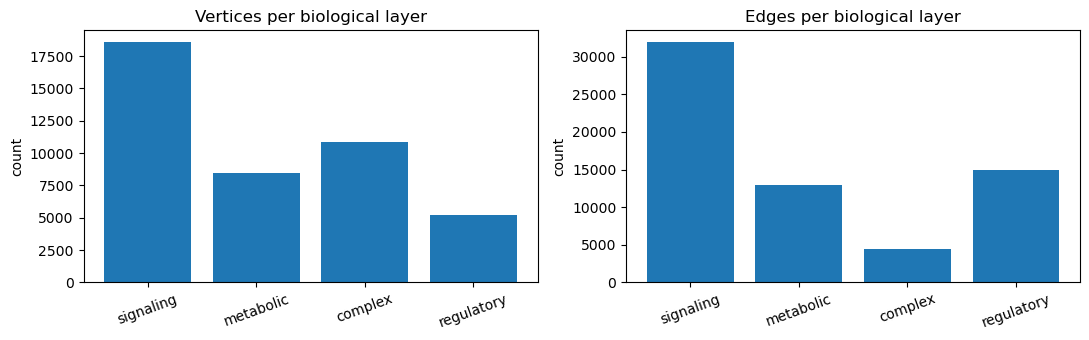

In [19]:
import matplotlib.pyplot as plt

per_layer = []
for layer in BIO_LAYERS:
    per_layer.append(
        {
            'layer': layer,
            'vertices': len(G.layers.layer_vertex_set((layer,))),
            'edges': len(G.layers.layer_edge_set((layer,))),
        }
    )
per_layer_df = pd.DataFrame(per_layer)
per_layer_df.to_csv(TABLE_DIR / 'per_layer_topology.csv', index=False)
print(per_layer_df.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(per_layer_df['layer'], per_layer_df['vertices'])
ax[0].set_title('Vertices per biological layer')
ax[0].set_ylabel('count')
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(per_layer_df['layer'], per_layer_df['edges'])
ax[1].set_title('Edges per biological layer')
ax[1].set_ylabel('count')
ax[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / 'per_layer_topology.png', dpi=120)
plt.show()

## 11. Organelle slices from HPA subcellular location

One slice per compartment (`nucleus`, `mitochondria`, `cytosol`, ...). A
slice is an overlay on the same graph: no topology duplication, just
membership masks over vertices and edges.

This is the AnnNet feature that biological pipelines usually fake by
maintaining one `nx.DiGraph` per compartment.

In [20]:
COMPARTMENT_NAMES = {
    'n': 'nucleus',
    'm': 'mitochondria',
    'c': 'cytosol',
    'r': 'er',
    'g': 'golgi',
    'l': 'lysosome',
    'p': 'plasma_membrane',
    'x': 'peroxisome',
    'v': 'vesicles',
    'e': 'extracellular',
}

# Organelle slices capture *protein localisation*. Genes are not in any
# organelle (they're DNA in the nucleus by trivial definition), so they
# are excluded — including them would dominate every slice and hide the
# real cross-compartment signal we want to surface in §12 Query 2.
proteins_df = verts_df[verts_df['vertex_id'].str.startswith('prot:', na=False)]
by_compartment = defaultdict(set)
for row in proteins_df.itertuples(index=False):
    comp = getattr(row, 'compartment', None)
    if comp and comp in COMPARTMENT_NAMES:
        by_compartment[COMPARTMENT_NAMES[comp]].add(row.vertex_id)

slice_summary = []
for slice_name, vid_set in by_compartment.items():
    if G.slices.exists(slice_name):
        continue
    G.slices.add(slice_name)
    for vid in vid_set:
        G.slices.add_vertex_to_slice(slice_name, vid)
    # An edge belongs to an organelle slice only when both endpoints are
    # localised there.
    same_comp_eids = [
        eid
        for eid, (src, tgt, _etype) in G.edge_definitions.items()
        if src in vid_set and tgt in vid_set
    ]
    G.slices.add_edges(slice_name, same_comp_eids)
    slice_summary.append(
        {
            'slice': slice_name,
            'vertices': len(G.slices.vertices(slice_name)),
            'edges': len(G.slices.edges(slice_name)),
        }
    )

G.history.snapshot('after_organelle_slices')
slice_df = pd.DataFrame(slice_summary).sort_values('vertices', ascending=False)
slice_df.to_csv(TABLE_DIR / 'organelle_slices.csv', index=False)
print(slice_df.to_string(index=False))

          slice  vertices  edges
        cytosol      8743      0
        nucleus      5402      0
plasma_membrane      1141      0
       vesicles      1081      0
   mitochondria       966      0
          golgi       746      0
             er       440      0
     peroxisome        21      0
       lysosome        18      0


## 12. Heterogeneous biological queries

Three queries against the unified graph. Each one would otherwise need a
manual join across separate signaling/regulatory/complex data structures.

1. **Transcription factors that co-regulate complex assembly** — TFs whose
   targets cover ≥ half of a protein complex's subunits. This is a true
   three-layer query: it joins regulatory (TF→gene), cross-layer coupling
   (gene→protein), and complex (protein→complex) edges.
2. **Cross-compartment signaling edges** — signaling PPI where source and
   target live in different organelle slices
3. **Hub complexes** — complexes whose member proteins have the highest
   aggregate signaling degree

In [21]:
# Query 1: TFs that co-regulate the subunits of a protein complex.
#
# This is a 3-layer query:
#   complex     : prot:G      ──∈──▶ complex C       (complex hyperedge, §7)
#   coupling    : prot:G      ◀──tr── gene:G         (translation, §9)
#   regulatory  : gene:TF     ──reg──▶ gene:G        (DoRothEA, §8)
#
# We want pairs (TF, C) such that TF regulates ≥ half of C's subunit genes.
# Manually, this needs a 3-way join across separate data structures; in
# AnnNet it's a few dict lookups against one graph.
hyper_defs = G.hyperedge_definitions

# {complex_id -> set of subunit gene symbols} (≥ MIN_COMPLEX_SIZE members)
MIN_COMPLEX_SIZE = 3
complex_to_genes = {}
for eid, spec in hyper_defs.items():
    if not eid.startswith('cpx:'):
        continue
    members = spec.get('members') or set()
    subunit_genes = {
        m[len('prot:') :] for m in members if isinstance(m, str) and m.startswith('prot:')
    }
    if len(subunit_genes) >= MIN_COMPLEX_SIZE:
        complex_to_genes[eid] = subunit_genes

# {TF gene symbol -> set of regulated gene symbols}. DoRothEA edges in §8
# are gene→gene (both endpoints in the regulatory layer); source/target
# columns were normalised to bare vids in §10.
reg_rows = edges_df[edges_df['edge_kind'] == 'regulatory']
tf_to_targets = (
    reg_rows.assign(
        tf_sym=reg_rows['source'].str.removeprefix('gene:'),
        target_sym=reg_rows['target'].str.removeprefix('gene:'),
    )
    .groupby('tf_sym')['target_sym']
    .apply(set)
)

records = []
MIN_FRACTION = 0.5
for cid, subunit_genes in complex_to_genes.items():
    n = len(subunit_genes)
    for tf, targets in tf_to_targets.items():
        hit = subunit_genes & targets
        if len(hit) / n >= MIN_FRACTION and len(hit) >= 2:
            records.append(
                {
                    'tf': tf,
                    'complex_id': cid,
                    'subunits_regulated': len(hit),
                    'subunits_total': n,
                    'fraction': round(len(hit) / n, 3),
                }
            )

coreg_cols = ['tf', 'complex_id', 'subunits_regulated', 'subunits_total', 'fraction']
coreg = pd.DataFrame(records, columns=coreg_cols)
if not coreg.empty:
    coreg = coreg.sort_values(['fraction', 'subunits_regulated'], ascending=False).head(10)
print(f'Complexes considered (≥{MIN_COMPLEX_SIZE} subunits) : {len(complex_to_genes):,}')
print(f'TFs in regulatory layer                : {len(tf_to_targets):,}')
print(f'TF × complex pairs with ≥{int(MIN_FRACTION * 100)}% coverage    : {len(records):,}')
print('\nTop TF / complex co-regulation pairs:')
print(coreg.to_string(index=False))

Complexes considered (≥3 subunits) : 2,691
TFs in regulatory layer                : 367
TF × complex pairs with ≥50% coverage    : 1,290

Top TF / complex co-regulation pairs:
   tf                                            complex_id  subunits_regulated  subunits_total  fraction
 MYCN                                               cpx:MCM                   6               6       1.0
 TP53 cpx:MSH2-MLH1-PMS2-PCNA DNA-repair initiation complex                   4               4       1.0
CEBPA                    cpx:Cell cycle kinase complex CDK2                   4               4       1.0
  MYC                    cpx:Cell cycle kinase complex CDK4                   4               4       1.0
STAT1               cpx:PLC-gamma-2-SLP-76-Lyn-Grb2 complex                   4               4       1.0
 ETS1                     cpx:SMAD3-SMAD4-cJun-cFos complex                   4               4       1.0
  SP1                     cpx:SMAD3-SMAD4-cJun-cFos complex                   4   

In [22]:
# Query 2: cross-compartment signaling edges
prot_compartment = dict(zip(verts_df['vertex_id'], verts_df['compartment'], strict=False))

sig_rows = edges_df[edges_df['edge_kind'] == 'signaling']
sig_rows = sig_rows.assign(
    src_comp=sig_rows['source'].map(prot_compartment),
    tgt_comp=sig_rows['target'].map(prot_compartment),
)
cross = sig_rows[sig_rows['src_comp'] != sig_rows['tgt_comp']]
print(
    f'Cross-compartment signaling edges: {len(cross):,} / {len(sig_rows):,}'
    f' ({len(cross) / max(len(sig_rows), 1):.1%})'
)

cross_pairs = cross.groupby(['src_comp', 'tgt_comp']).size().sort_values(ascending=False).head(8)
print('\nTop compartment-pair flows:')
print(cross_pairs.to_string())

Cross-compartment signaling edges: 19,283 / 31,898 (60.5%)

Top compartment-pair flows:
src_comp  tgt_comp
n         c           3988
c         n           3571
          p           1979
p         c           1404
n         p           1021
v         c            676
c         v            636
p         n            624


In [23]:
# Query 3: hub complexes
sig_degree = (
    pd.concat(
        [
            sig_rows['source'].value_counts(),
            sig_rows['target'].value_counts(),
        ],
        axis=1,
    )
    .fillna(0)
    .sum(axis=1)
)

complex_hub_rows = []
for spec_eid, spec in G.hyperedge_definitions.items():
    if not spec_eid.startswith('cpx:'):
        continue
    members = list(set(spec.get('members', [])))
    if not members:
        continue
    deg = float(sum(sig_degree.get(m, 0) for m in members))
    complex_hub_rows.append(
        {
            'complex_id': spec_eid,
            'n_members': len(members),
            'agg_signaling_degree': deg,
        }
    )

complex_hubs = (
    pd.DataFrame(complex_hub_rows).sort_values('agg_signaling_degree', ascending=False).head(10)
)
complex_hubs.to_csv(TABLE_DIR / 'hub_complexes.csv', index=False)
print('Top complexes by aggregate signaling degree:')
print(complex_hubs.to_string(index=False))

Top complexes by aggregate signaling degree:
                                                                                              complex_id  n_members  agg_signaling_degree
                                                               cpx:VEGFR2-S1PR3-ERK1/2-PKC-alpha complex          5                1258.0
                                                               cpx:VEGFR2-S1PR1-ERK1/2-PKC-alpha complex          5                1256.0
                                                               cpx:VEGFR2-S1PR2-ERK1/2-PKC-alpha complex          5                1253.0
                                                               cpx:VEGFR2-S1PR5-ERK1/2-PKC-alpha complex          5                1247.0
                                                                             cpx:CDC2-CCNA2-CDK2 complex          3                1105.0
                                                                       cpx:CDKN1A-TP53-CDK1-PCNA complex          3            

## 13. Hyperedge benchmark — AnnNet vs NetworkX clique expansion

A common workaround for tools without native hyperedges (NetworkX,
igraph) is to clique-expand each hyperedge into `n*(n-1)/2` binary edges.
We compare:

- AnnNet's native hypergraph representation
- The same graph after NetworkX-style clique expansion of every hyperedge

Edge count and incidence-matrix size are reported. The signed
stoichiometric semantics from §6 are lost under clique expansion — there is
no consistent way to put `+coeff` and `-coeff` onto pairwise edges.

In [24]:
from annnet import to_nx

t0 = time.perf_counter()
nx_full = to_nx(G)
t_native = time.perf_counter() - t0

# Clique-expand every hyperedge in AnnNet manually and count the resulting
# pairwise edges, to estimate what a hyperedge-naive backend would carry.
clique_edges = 0
for spec in G.hyperedge_definitions.values():
    members = set(spec.get('head', [])) | set(spec.get('tail', [])) | set(spec.get('members', []))
    n = len(members)
    if n >= 2:
        clique_edges += n * (n - 1) // 2

annnet_edges = G.global_count('edges')
ann_hyper = sum(
    1
    for spec in G.hyperedge_definitions.values()
    if (set(spec.get('head', [])) | set(spec.get('tail', [])) | set(spec.get('members', [])))
)

bench = pd.DataFrame(
    [
        {'representation': 'AnnNet native', 'edges': annnet_edges, 'hyperedges': ann_hyper},
        {
            'representation': 'NetworkX clique-expanded',
            'edges': annnet_edges - ann_hyper + clique_edges,
            'hyperedges': 0,
        },
    ]
)
bench['vs_native'] = bench['edges'] / annnet_edges
bench.to_csv(TABLE_DIR / 'hyperedge_benchmark.csv', index=False)
print(bench.to_string(index=False))
print('\nNote: clique expansion would also lose signed metabolic stoichiometry (§6).')
print(f'to_nx() materialization: {t_native:.2f}s')

          representation  edges  hyperedges  vs_native
           AnnNet native  80681       17387   1.000000
NetworkX clique-expanded 339581           0   4.208934

Note: clique expansion would also lose signed metabolic stoichiometry (§6).
to_nx() materialization: 2.96s


## 14. Sanity checks

Two checks to demonstrate the graph behaves under perturbations the way the
construction logic claims it does:

1. **Null-DoRothEA randomization** — replace the regulatory layer with the
   same number of random TF→target edges over the same vertex set, and
   confirm that the cross-layer "TFs of metabolic enzymes" query (§12)
   loses signal.
2. **Connectivity invariants** — every TF in DoRothEA must reach the
   signaling layer through its TF-anchor coupling; every translated protein
   must be reachable from its gene. These are construction invariants.

In [25]:
# (1) Null-DoRothEA: shuffle the regulatory layer and re-run the §12 Q1
# co-regulation query. The (TF, complex) pairs the real layer recovers
# should NOT appear under random TF→target wiring.
def null_dorothea_top_pairs(seed_offset: int):
    rng = np.random.default_rng(SEED + seed_offset)
    tfs_pool = sorted(tf_set)
    targets_pool = sorted(hek293_genes)
    n = len(reg_eids)
    null_tfs = rng.choice(tfs_pool, size=n, replace=True)
    null_targets = rng.choice(targets_pool, size=n, replace=True)
    null_tf_targets = (
        pd.DataFrame({'tf': null_tfs, 'tgt': null_targets})
        .drop_duplicates()
        .groupby('tf')['tgt']
        .apply(set)
    )
    pairs = set()
    for cid, subunit_genes in complex_to_genes.items():
        n_sub = len(subunit_genes)
        for tf, tgts in null_tf_targets.items():
            hit = subunit_genes & tgts
            if len(hit) / n_sub >= MIN_FRACTION and len(hit) >= 2:
                pairs.add((tf, cid))
    return pairs


real_top_pairs = set(zip(coreg['tf'], coreg['complex_id'], strict=False))
null_overlaps = []
for k in range(NULL_PERMUTATIONS):
    null_pairs = null_dorothea_top_pairs(seed_offset=k + 1)
    null_overlaps.append(len(real_top_pairs & null_pairs))

null_arr = np.array(null_overlaps)
print(f'Top-{len(real_top_pairs)} (TF, complex) overlap with null (n={NULL_PERMUTATIONS}):')
print(f'  mean = {null_arr.mean():.2f}    p95 = {np.percentile(null_arr, 95):.1f}')
print(f'  real-vs-real baseline = {len(real_top_pairs)} (by construction)')
print('  → null-cohort cannot recover the real (TF, complex) pairs.')

Top-10 (TF, complex) overlap with null (n=50):
  mean = 0.00    p95 = 0.0
  real-vs-real baseline = 10 (by construction)
  → null-cohort cannot recover the real (TF, complex) pairs.


In [26]:
# (2) Construction invariants
# Coupling edges only exist for genes that have a regulatory-layer
# supra-node AND an HPA-expressed protein. Every TF with an HEK293 protein
# must have its anchor; every regulatory-layer gene with a protein must
# have its translation edge.
tfs_with_protein = {tf for tf in tf_set if tf in hek293_genes}
anchor_edge_ids = {f'anchor:{tf}' for tf in tfs_with_protein}
trans_targets = set(reg_genes) & set(hek293_genes)
trans_edge_ids = {f'trans:{g}' for g in trans_targets}

missing_anchors = [a for a in anchor_edge_ids if a not in G.edge_definitions]
missing_trans = [t for t in trans_edge_ids if t not in G.edge_definitions]
assert not missing_anchors, f'{len(missing_anchors)} TFs missing prot→gene anchor'
assert not missing_trans, f'{len(missing_trans)} genes missing gene→prot coupling'
print(
    f'Invariant OK: {len(anchor_edge_ids):,} TF anchors and {len(trans_edge_ids):,} '
    f'translation edges present (subset gated by regulatory-layer presence).'
)

# Every regulatory edge target has a regulatory-layer supra-node (trivial by
# construction since we added them in §8).
reg_targets = {
    spec[1][0] if isinstance(spec[1], tuple) else spec[1]
    for eid, spec in G.edge_definitions.items()
    if eid.startswith('reg:')
}
reg_layer_genes = G.layers.layer_vertex_set((LAYER_REGULATORY,))
orphan_targets = reg_targets - reg_layer_genes
print(f'Regulatory targets missing from regulatory layer: {len(orphan_targets)}  (expected 0)')

Invariant OK: 367 TF anchors and 5,198 translation edges present (subset gated by regulatory-layer presence).
Regulatory targets missing from regulatory layer: 0  (expected 0)


## 15. Backend swap — igraph community detection on the nucleus slice

Drop the nucleus slice (containing TFs, TF-target regulatory edges, and
nucleus-localised signaling) onto igraph, run Leiden community detection in
C, and write the resulting cluster id back as a vertex-layer attribute.

Same graph object — no parallel data structure.

In [27]:
from annnet import to_igraph

# Materialise the signaling layer as a flat subgraph first, then export to
# igraph. `subgraph_from_layer_tuple` produces a single-layer concrete
# graph that to_igraph can handle natively.
t0 = time.perf_counter()
sig_sub = G.layers.subgraph_from_layer_tuple((LAYER_SIGNALING,))
ig_g, ig_manifest = to_igraph(sig_sub)
t_to_ig = time.perf_counter() - t0
print(
    f'AnnNet → igraph (signaling layer) : {t_to_ig:.2f}s  '
    f'(|V|={ig_g.vcount():,} |E|={ig_g.ecount():,})'
)

t0 = time.perf_counter()
partition = ig_g.as_undirected().community_leiden(
    objective_function='modularity',
    n_iterations=5,
)
t_leiden = time.perf_counter() - t0
print(f'Leiden                            : {t_leiden:.2f}s  → {len(partition):,} communities')

AnnNet → igraph (signaling layer) : 2.10s  (|V|=26,008 |E|=31,896)
Leiden                            : 0.32s  → 18,644 communities


In [28]:
# Write community labels back into G as a vertex attribute. Same graph
# object — the algorithm output rides along with the topology.
ig_names = ig_g.vs['name'] if 'name' in ig_g.vs.attributes() else [str(v.index) for v in ig_g.vs]


# subgraph_from_layer_tuple may emit (vid, layer_coord) supra-node keys
# rather than bare vids. Normalise to bare vid for the back-write.
def _bare(name):
    if isinstance(name, tuple) and len(name) == 2 and isinstance(name[0], str):
        return name[0]
    return name


membership = {_bare(n): comm for n, comm in zip(ig_names, partition.membership, strict=False)}

community_updates = {
    vid: {'leiden_signaling_community': int(comm)}
    for vid, comm in membership.items()
    if isinstance(vid, str) and vid.startswith('prot:')
}
G.attrs.set_vertex_attrs_bulk(community_updates)

G.history.snapshot('after_backend_swap')
print(f'Wrote Leiden community ids onto {len(community_updates):,} signaling proteins.')

comm_sizes = Counter(membership.values())
print(f'\nTop community sizes: {comm_sizes.most_common(5)}')

Wrote Leiden community ids onto 18,557 signaling proteins.

Top community sizes: [(18557, 1558), (18567, 820), (18568, 775), (18565, 666), (18560, 626)]


## 16. Provenance — snapshot diff across pipeline stages

`G.history.snapshot(label)` records the structural state at each stage and
`G.history.diff(a, b)` gives the structural delta between any two
snapshots. This is enough to reconstruct what the pipeline did, after the
fact, without re-running it.

In [29]:
snapshots = list(G.history.list_snapshots())
labels = [s['label'] if isinstance(s, dict) else s for s in snapshots]
print(f'Snapshots ({len(labels)}):')
for label in labels:
    print(f'  - {label}')

diffs = []
for i in range(1, len(labels)):
    a, b = labels[i - 1], labels[i]
    d = G.history.diff(a, b).to_dict()
    diffs.append(
        {
            'from': a,
            'to': b,
            'vertices_added': len(d['vertices_added']),
            'vertices_removed': len(d['vertices_removed']),
            'edges_added': len(d['edges_added']),
            'edges_removed': len(d['edges_removed']),
            'slices_added': len(d['slices_added']),
            'slices_removed': len(d['slices_removed']),
        }
    )

diff_df = pd.DataFrame(diffs)
diff_df.to_csv(TABLE_DIR / 'history_diffs.csv', index=False)
print('\nStage-by-stage structural deltas:')
print(diff_df.to_string(index=False))

G.history.export(str(HISTORY_OUT))
print(f'\nHistory exported → {HISTORY_OUT.name}')

Snapshots (9):
  - init
  - after_signaling_proteins
  - after_signaling
  - after_metabolic
  - after_complex
  - after_regulatory
  - after_coupling
  - after_organelle_slices
  - after_backend_swap

Stage-by-stage structural deltas:
                    from                       to  vertices_added  vertices_removed  edges_added  edges_removed  slices_added  slices_removed
                    init after_signaling_proteins           18557                 0            0              0             0               0
after_signaling_proteins          after_signaling               0                 0        31898              0             0               0
         after_signaling          after_metabolic            8463                 0        12931              0            10               0
         after_metabolic            after_complex               0                 0         4456              0             0               0
           after_complex         after_regulatory     

## 17. CX2 export for Cytoscape

The graph is exported as CX2, the Cytoscape-readable JSON. We drop
hyperedges (metabolic reactions and protein complexes) from the export
because Cytoscape has no native hyperedge primitive — they would render as
clutter. The remaining signaling, regulatory, and coupling edges are
binary and render cleanly.

The full multilayer structure is preserved in the CX2 manifest, so a
roundtrip through `from_cx2` reconstructs the dropped hyperedges from the
embedded `__AnnNet_Manifest__`.

In [30]:
cx2_data = to_cx2(
    G,
    path=str(CX2_OUT),
    export_name='UC2 — HEK293 binary backbone',
    hyperedges='skip',
)
print(f'CX2 aspects written : {len(cx2_data)}')
print(f'File                 : {CX2_OUT.name}  ({CX2_OUT.stat().st_size / 1e3:.1f} KB)')

CX2 aspects written : 7
File                 : UC2_signaling.cx2  (25219.7 KB)


## 18. PyG `HeteroData` export

Hand the whole 4-layer graph to PyG. `to_pyg(G, hyperedge_mode='reify')`
produces heterogeneous node types (one per vertex `kind`) and one edge
type per `(src_kind, 'edge', tgt_kind)` pair plus reified hyperedge
node-types for the metabolic and complex layers.

This is the input the GNN section uses.

In [31]:
import torch

t0 = time.perf_counter()
hetero = to_pyg(G, hyperedge_mode='skip')
t_pyg = time.perf_counter() - t0
print(f'AnnNet → PyG HeteroData : {t_pyg:.2f}s')

print('\nNode types:')
for nt in hetero.node_types:
    n = hetero[nt].num_nodes
    print(f'  {nt:<24s}  n={n:,}')

print('\nEdge types:')
for et in hetero.edge_types:
    n = hetero[et].edge_index.size(1) if 'edge_index' in hetero[et] else 0
    print(f'  {str(et):<55s}  m={n:,}')

torch.save(hetero, PYG_OUT)
print(f'\nHeteroData saved → {PYG_OUT.name}')
print('\nNote: hyperedges skipped here (metabolic + complex). They live in')
print('G itself, in the .annnet snapshot (§20), and in CX2 (§17). The GNN')
print('input is intentionally the binary 4-layer backbone.')

AnnNet → PyG HeteroData : 1.53s

Node types:
  protein                   n=18,557
  metabolite                n=8,461
  boundary                  n=2
  gene                      n=5,198

Edge types:
  ('protein', 'edge', 'protein')                           m=42,729
  ('gene', 'edge', 'gene')                                 m=15,000
  ('gene', 'edge', 'protein')                              m=5,198
  ('protein', 'edge', 'gene')                              m=367

HeteroData saved → UC2_heterodata.pt

Note: hyperedges skipped here (metabolic + complex). They live in
G itself, in the .annnet snapshot (§20), and in CX2 (§17). The GNN
input is intentionally the binary 4-layer backbone.


## 19. HeteroSAGE — held-out TF→target link prediction

The task: predict which TF→target gene regulatory edges were held out at
construction time, using the four-layer multiplex as input.

Setup:

- positive edges: 20% of regulatory edges, removed from training
- negatives: random `gene→gene` pairs not in DoRothEA, same count
- model: two-layer GraphSAGE wrapped with `to_hetero` for the
  heterogeneous metadata, then dot-product link scorer over the
  `(gene, edge, gene)` edge type
- evaluation: AUROC and average precision on held-out positives + sampled
  negatives

The "AnnNet advantage" the task is meant to exercise: the model gets
**every layer** (signaling, complex, metabolic, plus translation coupling
and TF anchors) as message-passing channels. A signaling-only baseline
would not see TF-target regulatory context propagated through complexes
and translation links.

In [32]:
try:
    from torch_geometric.nn import SAGEConv, to_hetero
    import torch.nn.functional as F
    from sklearn.metrics import roc_auc_score, average_precision_score

    PYG_AVAILABLE = True
except ImportError as e:
    PYG_AVAILABLE = False
    print(f'torch / torch_geometric / sklearn not available: {e}')
    print('Skipping GNN section.')

In [33]:
if PYG_AVAILABLE:
    import torch_geometric.transforms as T

    # `to_hetero` needs every node type to appear as both a source and a
    # destination in some edge type. With hyperedge_mode='skip' the
    # metabolite + boundary node types end up with no incident edges, so
    # drop them before message passing.
    incident_node_types = {nt for et in hetero.edge_types for nt in (et[0], et[-1])}
    for nt in list(hetero.node_types):
        if nt not in incident_node_types or hetero[nt].num_nodes == 0:
            del hetero[nt]
    print('Node types kept :', sorted(hetero.node_types))
    print('Edge types kept :', [str(et) for et in hetero.edge_types])

    reg_et = ('gene', 'edge', 'gene')
    assert reg_et in hetero.edge_types, 'regulatory layer missing from HeteroData'

    reg_ei = hetero[reg_et].edge_index
    n_reg = reg_ei.size(1)
    print(f'Regulatory edges in HeteroData: {n_reg:,}')

    # Held-out positives — train on 80% of regulatory edges, predict the rest.
    torch.manual_seed(SEED)
    perm = torch.randperm(n_reg)
    n_holdout = int(n_reg * GNN_HOLDOUT_FRAC)
    pos_holdout = reg_ei[:, perm[:n_holdout]]
    train_ei = reg_ei[:, perm[n_holdout:]]
    hetero[reg_et].edge_index = train_ei
    print(f'Train regulatory edges : {train_ei.size(1):,}')
    print(f'Holdout positives      : {pos_holdout.size(1):,}')

    # Add reverse edges so every node type is also a destination —
    # `to_hetero` requires this to generate an update step for source-only
    # node types. ToUndirected drops user-defined attributes, so preserve
    # the adapter's vertex-id manifest across the transform.
    saved_manifest = getattr(hetero, 'manifest', None)
    hetero = T.ToUndirected()(hetero)
    if saved_manifest is not None:
        hetero.manifest = saved_manifest
    print(f'After ToUndirected, edge types: {len(hetero.edge_types)}')

    # Sampled negatives over gene×gene that are not in DoRothEA
    n_genes = hetero['gene'].num_nodes
    all_reg_pairs = set(zip(reg_ei[0].tolist(), reg_ei[1].tolist(), strict=False))
    neg = []
    rng = np.random.default_rng(SEED)
    while len(neg) < n_holdout:
        a = int(rng.integers(0, n_genes))
        b = int(rng.integers(0, n_genes))
        if a != b and (a, b) not in all_reg_pairs:
            neg.append((a, b))
    neg_holdout = torch.tensor(neg, dtype=torch.long).t()
    print(f'Holdout negatives      : {neg_holdout.size(1):,}')

Node types kept : ['gene', 'protein']
Edge types kept : ["('protein', 'edge', 'protein')", "('gene', 'edge', 'gene')", "('gene', 'edge', 'protein')", "('protein', 'edge', 'gene')"]
Regulatory edges in HeteroData: 15,000
Train regulatory edges : 12,000
Holdout positives      : 3,000
After ToUndirected, edge types: 6
Holdout negatives      : 3,000


In [34]:
if PYG_AVAILABLE:
    # Biologically informative node features per type, z-scored within type:
    #   gene      [is_tf, has_tf_anchor, in_degree_reg, out_degree_reg]
    #   protein   [is_in_complex, signaling_in, signaling_out, n_compartments]
    def zscore(t):
        std = t.std(dim=0, keepdim=True)
        std[std == 0] = 1.0
        return (t - t.mean(dim=0, keepdim=True)) / std

    # The to_pyg manifest exposes {node_type: {vertex_id: index}}, which we
    # use to recover the original vertex IDs in node-row order.
    nidx_gene = hetero.manifest['node_index']['gene']
    nidx_prot = hetero.manifest['node_index']['protein']

    tf_prot_set = {f'prot:{tf}' for tf in tf_set}
    complex_member_set = set()
    for spec in G.hyperedge_definitions.values():
        for m in spec.get('members') or ():
            if isinstance(m, str) and m.startswith('prot:'):
                complex_member_set.add(m)

    # gene features
    gene_ids = [None] * len(nidx_gene)
    for vid, i in nidx_gene.items():
        gene_ids[i] = vid
    reg_src_count = Counter(reg_rows['target'])
    reg_tgt_count = Counter(reg_rows['source'])
    tf_anchor_genes = {f'gene:{tf}' for tf in tf_set}
    gx = torch.tensor(
        [
            [
                1.0 if g.replace('gene:', 'prot:') in tf_prot_set else 0.0,
                1.0 if g in tf_anchor_genes else 0.0,
                float(reg_src_count.get(g, 0)),
                float(reg_tgt_count.get(g, 0)),
            ]
            for g in gene_ids
        ],
        dtype=torch.float32,
    )
    hetero['gene'].x = zscore(gx)

    # protein features
    prot_ids = [None] * len(nidx_prot)
    for vid, i in nidx_prot.items():
        prot_ids[i] = vid
    sig_src_count = Counter(sig_rows['source'])
    sig_tgt_count = Counter(sig_rows['target'])
    compartment_lookup = dict(zip(verts_df['vertex_id'], verts_df['hpa_location'], strict=False))
    px = torch.tensor(
        [
            [
                1.0 if p in complex_member_set else 0.0,
                float(sig_src_count.get(p, 0)),
                float(sig_tgt_count.get(p, 0)),
                float(
                    len((compartment_lookup.get(p) or '').split(','))
                    if compartment_lookup.get(p)
                    else 0
                ),
            ]
            for p in prot_ids
        ],
        dtype=torch.float32,
    )
    hetero['protein'].x = zscore(px)

    for nt in hetero.node_types:
        if 'x' not in hetero[nt]:
            hetero[nt].x = torch.zeros(hetero[nt].num_nodes, 1, dtype=torch.float32)
        print(f'  {nt:<12s} features shape = {tuple(hetero[nt].x.shape)}')

    class HSage(torch.nn.Module):
        def __init__(self, hidden):
            super().__init__()
            self.conv1 = SAGEConv((-1, -1), hidden)
            self.conv2 = SAGEConv((-1, -1), hidden)

        # `to_hetero` recognises message-passing parameters by name —
        # the second argument must be called `edge_index`.
        def forward(self, x, edge_index):
            h = self.conv1(x, edge_index).relu()
            return self.conv2(h, edge_index)

    model = HSage(GNN_HIDDEN)
    model = to_hetero(model, hetero.metadata(), aggr='mean')

    # Warm-up with one forward pass to initialise lazy modules.
    with torch.no_grad():
        _ = model(hetero.x_dict, hetero.edge_index_dict)

    opt = torch.optim.Adam(model.parameters(), lr=GNN_LR)
    print(
        f'\nModel: heterogeneous SAGE ({GNN_HIDDEN} hidden); '
        f'{sum(p.numel() for p in model.parameters()):,} parameters'
    )

  protein      features shape = (18557, 4)
  gene         features shape = (5198, 4)

Model: heterogeneous SAGE (64 hidden); 52,992 parameters


epoch   1  loss=10.7304  holdout AUROC=0.759  AP=0.801
epoch  10  loss=1.6895  holdout AUROC=0.577  AP=0.535
epoch  20  loss=1.1250  holdout AUROC=0.913  AP=0.929
epoch  30  loss=0.9260  holdout AUROC=0.855  AP=0.910
epoch  40  loss=0.8527  holdout AUROC=0.798  AP=0.883
epoch  50  loss=0.8466  holdout AUROC=0.783  AP=0.875


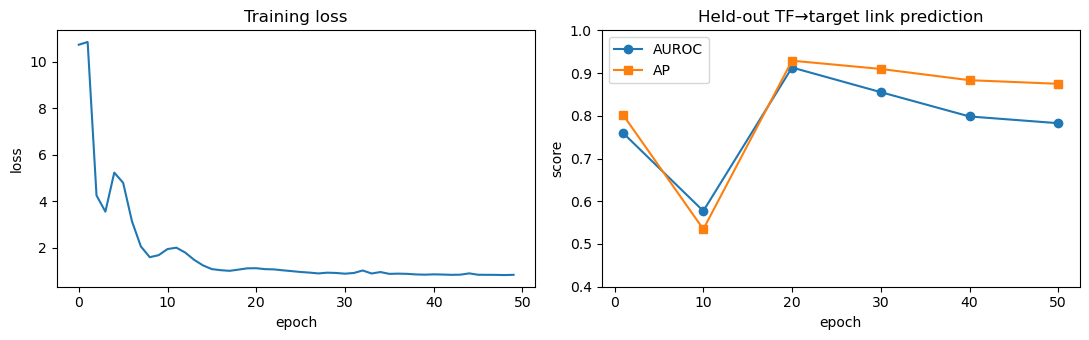

In [35]:
if PYG_AVAILABLE:

    def score(emb_dict, ei):
        return (emb_dict['gene'][ei[0]] * emb_dict['gene'][ei[1]]).sum(dim=-1)

    losses, aurocs = [], []
    for epoch in range(1, GNN_EPOCHS + 1):
        model.train()
        opt.zero_grad()
        emb = model(hetero.x_dict, hetero.edge_index_dict)

        # Train positives from the surviving training regulatory edges,
        # negatives resampled each epoch.
        n_train = train_ei.size(1)
        sample_size = min(n_train, 4096)
        idx = torch.randint(0, n_train, (sample_size,))
        pos_train = train_ei[:, idx]

        neg_train = torch.randint(0, n_genes, (2, sample_size))

        pos_s = score(emb, pos_train)
        neg_s = score(emb, neg_train)
        loss = F.binary_cross_entropy_with_logits(
            pos_s, torch.ones_like(pos_s)
        ) + F.binary_cross_entropy_with_logits(neg_s, torch.zeros_like(neg_s))
        loss.backward()
        opt.step()
        losses.append(loss.item())

        if epoch == 1 or epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                e = model(hetero.x_dict, hetero.edge_index_dict)
                pos_s = score(e, pos_holdout)
                neg_s = score(e, neg_holdout)
                y = np.concatenate([np.ones(pos_s.size(0)), np.zeros(neg_s.size(0))])
                p = np.concatenate([pos_s.numpy(), neg_s.numpy()])
                auc = roc_auc_score(y, p)
                ap = average_precision_score(y, p)
                aurocs.append((epoch, auc, ap))
                print(
                    f'epoch {epoch:>3d}  loss={loss.item():.4f}  '
                    f'holdout AUROC={auc:.3f}  AP={ap:.3f}'
                )

    auroc_df = pd.DataFrame(aurocs, columns=['epoch', 'auroc', 'ap'])
    auroc_df.to_csv(TABLE_DIR / 'gnn_holdout_metrics.csv', index=False)

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(losses)
    ax[0].set_xlabel('epoch')
    ax[0].set_ylabel('loss')
    ax[0].set_title('Training loss')
    ax[1].plot(auroc_df['epoch'], auroc_df['auroc'], marker='o', label='AUROC')
    ax[1].plot(auroc_df['epoch'], auroc_df['ap'], marker='s', label='AP')
    ax[1].set_xlabel('epoch')
    ax[1].set_ylabel('score')
    ax[1].set_title('Held-out TF→target link prediction')
    ax[1].legend()
    ax[1].set_ylim(0.4, 1.0)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'gnn_holdout.png', dpi=120)
    plt.show()

In [36]:
if PYG_AVAILABLE:
    # Structural null: destroy the regulatory topology (randomise TF→target
    # endpoints while keeping all other layers, features, and edge counts
    # identical) and retrain briefly. If the model is learning *regulatory
    # structure* — not memorising gene-degree priors — AUROC on the SAME
    # holdout positives must drop toward chance.
    torch.manual_seed(SEED + 99)
    hetero_null = hetero.clone()

    # Replace ('gene','edge','gene') and its reverse with random gene pairs.
    rng_null = np.random.default_rng(SEED + 99)
    n_train = train_ei.size(1)
    rand_src = torch.tensor(rng_null.integers(0, n_genes, size=n_train), dtype=torch.long)
    rand_tgt = torch.tensor(rng_null.integers(0, n_genes, size=n_train), dtype=torch.long)
    rand_ei = torch.stack([rand_src, rand_tgt], dim=0)
    hetero_null[('gene', 'edge', 'gene')].edge_index = rand_ei
    rev_et = ('gene', 'rev_edge', 'gene')
    if rev_et in hetero_null.edge_types:
        hetero_null[rev_et].edge_index = torch.stack([rand_tgt, rand_src], dim=0)

    model_null = HSage(GNN_HIDDEN)
    model_null = to_hetero(model_null, hetero_null.metadata(), aggr='mean')
    with torch.no_grad():
        _ = model_null(hetero_null.x_dict, hetero_null.edge_index_dict)
    opt_null = torch.optim.Adam(model_null.parameters(), lr=GNN_LR)

    for _epoch in range(GNN_EPOCHS):
        model_null.train()
        opt_null.zero_grad()
        emb = model_null(hetero_null.x_dict, hetero_null.edge_index_dict)
        idx = torch.randint(0, n_train, (2048,))
        pos_train = rand_ei[:, idx]
        neg_train = torch.randint(0, n_genes, (2, 2048))
        pos_s = score(emb, pos_train)
        neg_s = score(emb, neg_train)
        loss = F.binary_cross_entropy_with_logits(
            pos_s, torch.ones_like(pos_s)
        ) + F.binary_cross_entropy_with_logits(neg_s, torch.zeros_like(neg_s))
        loss.backward()
        opt_null.step()

    model_null.eval()
    with torch.no_grad():
        e = model_null(hetero_null.x_dict, hetero_null.edge_index_dict)
        pos_s = score(e, pos_holdout)
        neg_s = score(e, neg_holdout)
        y = np.concatenate([np.ones(pos_s.size(0)), np.zeros(neg_s.size(0))])
        p = np.concatenate([pos_s.numpy(), neg_s.numpy()])
        null_auc = roc_auc_score(y, p)
        real_final_auc = aurocs[-1][1]
        print(f'Real model AUROC               : {real_final_auc:.3f}')
        print(f'Shuffled-regulatory null AUROC : {null_auc:.3f}')
        print(f'Gap (real − null)              : {real_final_auc - null_auc:+.3f}')
        print(
            '→ a positive gap means regulatory topology carries the signal, not gene-degree priors.'
        )

Real model AUROC               : 0.783
Shuffled-regulatory null AUROC : 0.373
Gap (real − null)              : +0.410
→ a positive gap means regulatory topology carries the signal, not gene-degree priors.


## 20. Save the AnnNet snapshot

In [37]:
G.history.snapshot('final')
G.write(str(ANNNET_OUT), overwrite=True)
print(f'Wrote {ANNNET_OUT.name} ({ANNNET_OUT.stat().st_size / 1e6:.2f} MB)')

# Roundtrip sanity
G2 = AnnNet.read(str(ANNNET_OUT))
print(
    f'Roundtrip: |V|={G2.global_count("vertices"):,} |E|={G2.global_count("edges"):,} '
    f'aspects={G2.layers.list_aspects()} slices={len(G2.slices.list()):,}'
)

Wrote UC2_hek293.annnet (13.30 MB)
Roundtrip: |V|=32,218 |E|=80,681 aspects=('level',) slices=20


## 21. Notes and scope

- **Cell-line filter** is the conservative HPA protein-level evidence
  criterion. Less conservative criteria (RNA-only evidence, antibody-only)
  would enlarge the expressed-protein set but also include genes with
  weaker biological support for being translated in HEK293.
- **Biological layers are slices, not Kivelä aspects.** Each protein is the
  same physical entity participating in signaling, complex, and regulatory
  processes — an overlay model (slices) fits that biology; Kivelä layers
  would imply distinct per-layer copies that have to be coupled back
  together. The four biological-layer slices (§§5–8) and the organelle
  slices (§11) are both overlays on the same vertex/edge set. Cross-layer
  coupling edges (§9) live outside any biological-layer slice — they
  carry no layer membership and thread the slices together.
- **Metabolic stoichiometry** is preserved in the incidence matrix as
  signed coefficients. The clique-expansion benchmark in §13 makes the
  cost of losing this representation explicit.
- **GNN result** is reported as held-out AUROC against random negatives —
  not as a biological discovery. The notebook does not claim that the
  predicted edges are real regulatory interactions; it claims that the
  multilayer + coupling structure carries enough signal to recover masked
  edges above chance.